<a href="https://colab.research.google.com/github/rshewatkar/Ship_Co2_Emission_Prediction/blob/main/Ship_Co2_Emission_Prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jeleeladekunlefijabi/ship-fuel-consumption-and-co2-emissions-analysis")

print("Path to dataset files:", path)

100%|██████████| 30.0k/30.0k [00:00<00:00, 183kB/s]

Extracting files...


Path to dataset files: C:\Users\rshew\.cache\kagglehub\datasets\jeleeladekunlefijabi\ship-fuel-consumption-and-co2-emissions-analysis\versions\1


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [6]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_files

['ship_fuel_efficiency.csv']

In [7]:
ship_df = pd.read_csv(os.path.join(path, csv_files[0]))
ship_df.head()

,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61


In [8]:
df = ship_df.copy()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ship_id             1440 non-null   object 
 1   ship_type           1440 non-null   object 
 2   route_id            1440 non-null   object 
 3   month               1440 non-null   object 
 4   distance            1440 non-null   float64
 5   fuel_type           1440 non-null   object 
 6   fuel_consumption    1440 non-null   float64
 7   CO2_emissions       1440 non-null   float64
 8   weather_conditions  1440 non-null   object 
 9   engine_efficiency   1440 non-null   float64
dtypes: float64(4), object(6)
memory usage: 112.6+ KB


In [10]:
df.isnull().sum().sort_values(ascending=False)

ship_id               0
ship_type             0
route_id              0
month                 0
distance              0
fuel_type             0
fuel_consumption      0
CO2_emissions         0
weather_conditions    0
engine_efficiency     0
dtype: int64

In [11]:
df.describe()

,distance,fuel_consumption,CO2_emissions,engine_efficiency
count,1440.000000,1440.000000,1440.000000,1440.000000
mean,151.753354,4844.246535,13365.454882,82.582924
std,108.472230,4892.352813,13567.650118,7.158289
min,20.080000,237.880000,615.680000,70.010000
25%,79.002500,1837.962500,4991.485000,76.255000
50%,123.465000,3060.880000,8423.255000,82.775000
75%,180.780000,4870.675000,13447.120000,88.862500
max,498.550000,24648.520000,71871.210000,94.980000


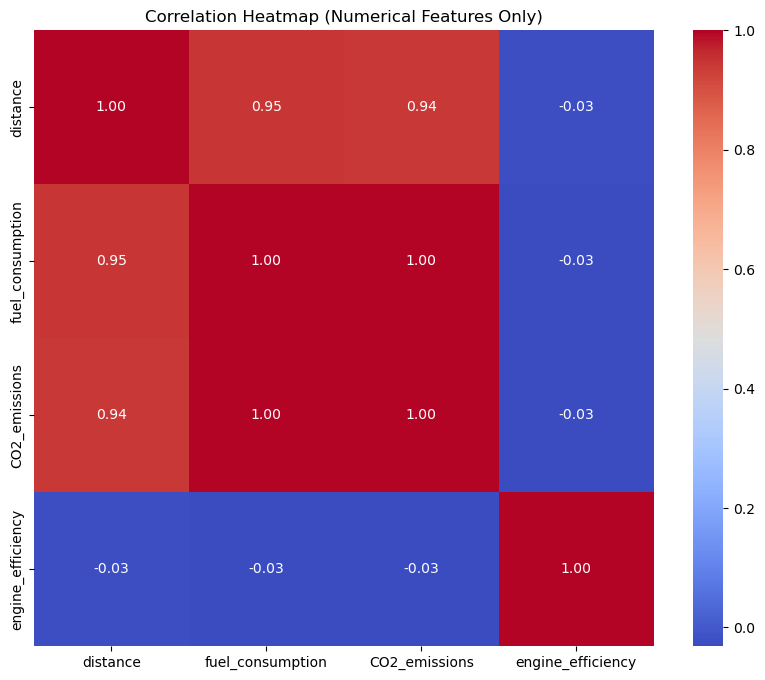

In [12]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Step 1: Define X and y
X = df.drop("CO2_emissions", axis=1)
y = df["CO2_emissions"]

# Step 2: Convert categorical features to numerical using one-hot encoding
X.columns = X.columns.str.replace(" ", "_")
X = pd.get_dummies(X, drop_first=True) # drop_first=True to avoid multicollinearity

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Models
models = {
    "XGBoost":       XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "LightGBM":      LGBMRegressor(n_estimators=200, random_state=42),
    "Linear Reg.":   LinearRegression()
}

# Step 5: Training loop
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE":  mean_absolute_error(y_test, preds),
        "R2":   r2_score(y_test, preds)
    }

# Step 6: Results
print(pd.DataFrame(results).T.sort_values("R2", ascending=False))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000216 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 805
[LightGBM] [Info] Number of data points in the train set: 1152, number of used features: 23
[LightGBM] [Info] Start training from score 13215.458110
                      RMSE         MAE        R2
Random Forest  1011.922522  607.408120  0.995069
XGBoost        1119.183341  632.071959  0.993969
Linear Reg.    1125.663912  703.153641  0.993898
LightGBM       1297.590826  690.190202  0.991892


In [16]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

categorical_cols = X.select_dtypes(include="object").columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

In [17]:
from sklearn.ensemble import RandomForestRegressor
final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

final_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [18]:
import joblib

joblib.dump(final_model, "rf_model_v1.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")
joblib.dump(le_dict, "encoders.pkl")

['encoders.pkl']

In [19]:
import pandas as pd

importance = pd.Series(final_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

fuel_consumption               0.995849
engine_efficiency              0.000986
distance                       0.000859
ship_id_NG012                  0.000200
weather_conditions_Moderate    0.000131
fuel_type_HFO                  0.000125
month_March                    0.000107
month_February                 0.000102
month_September                0.000098
weather_conditions_Stormy      0.000098
dtype: float64